In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DS_H_Features Face_Parts/DS_H_Features LowerFace(HS).csv'
df = pd.read_csv(file_path)

In [ ]:
#Dropping the target coloumn (DownSyndromeStatus) and 'image_name' column as it's not relevant for prediction
X=df.drop(['DownSyndromeStatus','image_name'],axis=1)
y=df['DownSyndromeStatus']

In [ ]:
scaler= StandardScaler()
X= scaler.fit_transform(X)

In [ ]:
#Reshaping input data to be 2D (e.g., if 20 features, reshape to (4, 5, 1))
num_samples, num_features = X.shape

#Calculating the closest perfect square to num_features
import math
dim = int(math.sqrt(num_features))
closest_square = dim * dim

#Reshaping X using the closest perfect square
X = X[:, :closest_square].reshape((num_samples, dim, dim, 1))  #will Select only necessary features and reshape

#Printing the new shape of X
print("New shape of X:", X.shape)

New shape of X: (2968, 45, 45, 1)


In [ ]:
#First split to get test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

#Second split to get train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42)

In [ ]:
def create_model(input_shape):
    model = models.Sequential()

    #Convolutional Layer 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    #Convolutional Layer 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    #Flatten and Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

#Creating and compiling the model
input_shape = X_train.shape[1:]  #shape of one sample
model = create_model(input_shape)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 43, 43, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 21, 21, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 19, 19, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 9, 9, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5184)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         331,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 350,721 (1.34 MB)

 Trainable params: 350,721 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.5169 - loss: 0.7971 - val_accuracy: 0.5620 - val_loss: 0.6686
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.5867 - loss: 0.6716 - val_accuracy: 0.7098 - val_loss: 0.6202
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.6740 - loss: 0.6091 - val_accuracy: 0.6966 - val_loss: 0.5692
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.7728 - loss: 0.5012 - val_accuracy: 0.7546 - val_loss: 0.4943
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.8036 - loss: 0.4319 - val_accuracy: 0.7731 - val_loss: 0.4752
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.8391 - loss: 0.3760 - val_accuracy: 0.7784 - val_loss: 0.4873
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8595 - loss: 0.3338 - val_accuracy: 0.7678 - val_loss: 0.5203
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9075 - loss: 0.2419 - val_accuracy: 0.7309

In [ ]:
#Predicting probabilities for positive class
y_pred_proba = model.predict(X_test).ravel() #Changing classifier to model and X_test_encoded to X_test
y_pred = (y_pred_proba > 0.5).astype(int)

#Converting probabilities to binary predictions
#Accuracy
from sklearn.metrics import accuracy_score, classification_report # Added import statements
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

#Classification Report
report = classification_report(y_test, y_pred, target_names=['Healthy', 'Down Syndrome'])
print("Classification Report:")
print(report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Accuracy: 0.75
Classification Report:
               precision    recall  f1-score   support

      Healthy       0.76      0.74      0.75       225
Down Syndrome       0.74      0.76      0.75       221

     accuracy                           0.75       446
    macro avg       0.75      0.75      0.75       446
 weighted avg       0.75      0.75      0.75       446



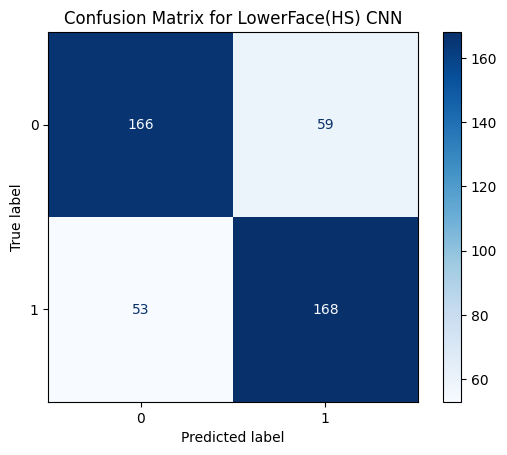

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for LowerFace(HS) CNN")
plt.show()

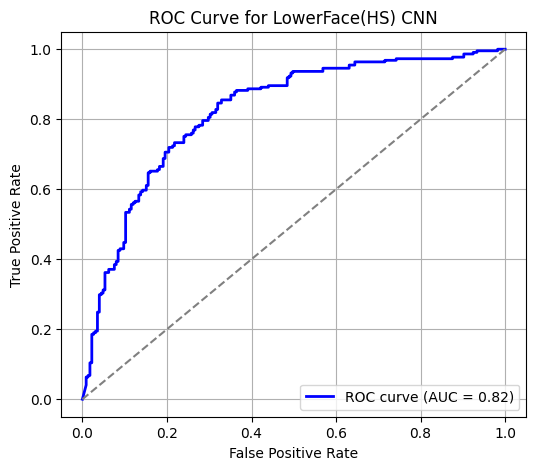

In [ ]:
#Calculating fpr, tpr, and roc_auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

#Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

#Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LowerFace(HS) CNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()